# PSA/VSA 경제성 최적화 노트북

이 노트북은 `model_shap.ipynb`의 surrogate 모델 구조와 `pas.py`의 전처리/물질수지 아이디어를 이용해서, 입력 가스 상태별 최적 운전조건을 찾기 위한 실행용 워크플로우입니다.

최적화 목적은 `CO2 1톤당 총비용 최소화`이며, 주요 조작변수는 다음 5개입니다.
- `tADS`
- `PL`
- `v0`
- `t_press`
- `t_depress`


In [1]:
# 기본 라이브러리와 최적화 모듈을 불러온다.
# 실행 위치가 루트이든 model 폴더이든 동작하도록 경로를 보정한다.

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
candidate_module_dirs = [
    cwd,
    cwd / 'mof' / 'optimization',
    cwd.parent / 'optimization',
]
module_dir = next((path for path in candidate_module_dirs if (path / 'optimize_policy.py').exists()), None)
if module_dir is None:
    raise FileNotFoundError('optimize_policy.py를 찾을 수 없습니다. 노트북 실행 위치를 확인하세요.')

model_dir = module_dir.parent / 'model'
dataset_dir = module_dir.parent / 'dataset'

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from optimize_policy import (
    PSAEconomicsOptimizer,
    CostConfig,
    ProcessConstants,
    GAS_STATE_COLS,
    FACTOR_COLS,
    load_training_data,
    load_fixed_inputs,
    normalize_fixed_input,
    summarize_result,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorfl

## 1. 학습 데이터 로드 및 surrogate optimizer 초기화

여기서는 `model/output.csv`를 학습 데이터로 사용합니다. 이 파일에서 `status == 'ok'` 인 데이터만 사용해서 purity / recovery surrogate를 다시 학습합니다.

In [2]:
# 현재 작업 경로에 따라 데이터 경로를 자동으로 맞춘다.

base_dir = module_dir
default_train_candidates = [
    model_dir / 'output.csv',
    dataset_dir / 'data.csv',
    dataset_dir / 'test.csv',
]
train_csv = next((path for path in default_train_candidates if path.exists()), None)
if train_csv is None:
    raise FileNotFoundError('학습용 CSV를 찾지 못했습니다. train_csv 경로를 직접 지정하세요.')

purity_model_path = model_dir / 'CO2_purity_dnn.keras'
recovery_model_path = model_dir / 'CO2_recovery_dnn.keras'
for model_path in [purity_model_path, recovery_model_path]:
    if not model_path.exists():
        raise FileNotFoundError(f'모델 파일이 없습니다: {model_path}')

train_df = load_training_data(train_csv)
print(f'학습 데이터 경로: {train_csv}')
print(f'원본 학습 데이터 shape: {train_df.shape}')

# 공정 상수와 비용 가정은 dataclass로 분리되어 있다.
# 아래 숫자는 비교용 기본값이므로, 실제 사업 조건에 맞게 수정하면 된다.

process_constants = ProcessConstants(
    temperature_k=313.15,
    high_pressure_bar=1.2,
    bed_length_m=1.0,
    area_m2=0.01,
    bed_void_fraction=0.39,
    particle_diameter_m=1.2e-3,
    operating_hours_per_year=8000.0,
)

cost_config = CostConfig(
    electricity_cost_per_kwh=110.0,
    carbon_price_per_tco2=50000.0,
    co2_credit_per_tco2=0.0,
    annualized_capex_per_m3_bed=200000.0,
    annual_fixed_om_per_m3_bed=40000.0,
    annual_adsorbent_budget_per_m3_bed=80000.0,
    purity_target=0.90,
    recovery_target=0.90,
    purity_penalty_weight=200000.0,
    recovery_penalty_weight=250000.0,
    uncertainty_penalty_weight=50000.0,
)

optimizer = PSAEconomicsOptimizer(
    train_df=train_df,
    purity_model_path=purity_model_path,
    recovery_model_path=recovery_model_path,
    constants=process_constants,
    cost=cost_config,
)

print(f'유효 학습 데이터 shape: {optimizer.train_df.shape}')
optimizer.train_df.head()


학습 데이터 경로: C:\Users\junhyun111\Desktop\psa\mof\dataset\data.csv
원본 학습 데이터 shape: (900, 35)
유효 학습 데이터 shape: (900, 35)


,Unnamed: 0,sample_id,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail,valid_physics,status_detail,n_cycles,status
0,0,1,121.231639,0.242283,0.011761,64.864674,38.008555,27.906160,0.988694,7.974843,0.079348,0.183007,0.816986,0.840412,0.895745,0.945157,1.058946,0.522849,0.163898,0.637936,0.046904,0.209381,0.029921,0.152640,11.255814,0.149594,11.460740,0.799046,0.200954,0.204926,0.051537,True,ok,10,ok
1,1,2,163.806902,0.338393,0.028594,59.693324,65.954041,9.681633,0.884149,6.019091,0.087091,0.235562,0.764434,0.866624,0.913090,0.952002,1.056361,0.415982,0.490516,0.692717,0.198327,0.643589,0.137384,0.142697,7.030726,0.129357,7.147577,0.696158,0.303842,0.116850,0.051000,True,ok,10,ok
2,2,3,82.472037,0.230902,0.022071,50.168231,40.971812,43.930029,0.138311,2.153061,0.049224,0.197930,0.802061,0.894359,0.938445,0.968546,1.034702,0.355460,0.227966,0.690067,0.064763,0.262424,0.044691,0.151351,12.074274,0.146860,12.263334,0.789300,0.210700,0.189060,0.050469,True,ok,10,ok
3,3,4,96.366813,0.162668,0.021114,53.254276,26.810740,57.544259,0.723156,7.336068,0.048012,0.249925,0.750059,0.847753,0.901771,0.952673,1.045096,0.514483,0.317861,0.722666,0.091411,0.274318,0.066059,0.141765,14.988749,0.140240,15.151836,0.781032,0.218968,0.163086,0.045722,True,ok,10,ok
4,4,5,113.613987,0.180127,0.031534,20.341739,60.884987,44.615595,0.020142,9.788497,0.033695,0.215893,0.784096,0.883246,0.932161,0.973748,1.043018,0.407473,0.389094,0.708194,0.139038,0.504942,0.098466,0.154598,13.522129,0.147633,13.635937,0.700612,0.299388,0.113808,0.048633,True,ok,10,ok


## 2. 최적화 대상 입력 가스 상태 정의

아래 `fixed_inputs_df`를 직접 수정하거나 `fixed_inputs_csv`를 지정해서 원하는 케이스를 넣으면 됩니다.

필수 컬럼:
- `co2_mol_frac`
- `h2o_ppmv`
- `sox_ppmv`
- `nox_ppmv`
- `dust_mg_Nm3`

In [3]:
# 최적화에 넣을 고정 입력 케이스를 정의한다.
# fixed_inputs_csv를 지정하면 외부 CSV를 읽고, None이면 아래 예시를 사용한다.

fixed_inputs_csv = None
# fixed_inputs_csv = dataset_dir / 'test.csv'

if fixed_inputs_csv is not None:
    fixed_inputs_df = load_fixed_inputs(Path(fixed_inputs_csv), optimizer.train_df)
else:
    fixed_inputs_df = pd.DataFrame([
        {
            'co2_mol_frac': 0.18,
            'h2o_ppmv': 10.0,
            'sox_ppmv': 0.20,
            'nox_ppmv': 3.0,
            'dust_mg_Nm3': 0.02,
        },
        {
            'co2_mol_frac': 0.22,
            'h2o_ppmv': 20.0,
            'sox_ppmv': 0.10,
            'nox_ppmv': 2.0,
            'dust_mg_Nm3': 0.01,
        },
    ])
    missing_cols = [col for col in GAS_STATE_COLS if col not in fixed_inputs_df.columns]
    if missing_cols:
        raise ValueError(f'고정 입력 컬럼 누락: {missing_cols}')
    fixed_inputs_df = pd.DataFrame([
        normalize_fixed_input(row.to_dict())
        for _, row in fixed_inputs_df.iterrows()
    ])

missing_cols = [col for col in GAS_STATE_COLS if col not in fixed_inputs_df.columns]
if missing_cols:
    raise ValueError(f'고정 입력 컬럼 누락: {missing_cols}')

fixed_inputs_df[GAS_STATE_COLS + FACTOR_COLS]


,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index
0,0.18,10.0,0.2,3.0,0.02,0.917934,0.948119,0.979011,1.020196,0.251851
1,0.22,20.0,0.1,2.0,0.01,0.915725,0.947814,0.979508,1.015097,0.270889


## 3. 최적화 실행

전역 탐색은 LHS 기반으로 하고, 이후 상위 해 주변에서 국소 탐색을 반복합니다.

주요 파라미터:
- `n_samples`: 초기 후보 수
- `local_steps`: 국소 탐색 반복 횟수
- `elite_size`: 각 단계에서 확장할 상위 해 개수

정확도를 높이려면 `n_samples`를 올리면 되지만 계산 시간도 함께 증가합니다.

In [4]:
# 최적화 탐색 파라미터를 설정한다.
# 빠른 테스트는 작게, 실제 분석은 더 크게 잡는 것이 좋다.

n_samples = 4000
local_steps = 6
elite_size = 12
seed = 42

summary_rows = []
candidate_frames = []

for case_id, fixed_input in fixed_inputs_df.iterrows():
    print(f'[최적화 시작] case_id={case_id + 1}')

    best, evaluated = optimizer.optimize_for_fixed_input(
        fixed_input=fixed_input.to_dict(),
        n_samples=n_samples,
        local_steps=local_steps,
        elite_size=elite_size,
        seed=seed + case_id,
    )

    summary_rows.append(summarize_result(case_id + 1, fixed_input, best))

    # 전체 후보 테이블은 사후 분석용으로 저장한다.
    evaluated = evaluated.copy()
    evaluated.insert(0, 'case_id', case_id + 1)
    for col in GAS_STATE_COLS + FACTOR_COLS:
        evaluated[col] = fixed_input[col]
    candidate_frames.append(evaluated)

summary_df = pd.DataFrame(summary_rows)
all_candidates_df = pd.concat(candidate_frames, ignore_index=True)

summary_df


[최적화 시작] case_id=1
[최적화 시작] case_id=2


,case_id,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,opt_tADS,opt_PL,opt_v0,opt_t_press,opt_t_depress,pred_CO2_purity,pred_CO2_recovery,n_CO2_product_calc,n_N2_product_calc,specific_energy_kwh_per_tco2,energy_cost_per_tco2,capex_proxy_cost_per_tco2,fixed_om_cost_per_tco2,adsorbent_cost_per_tco2,unrecovered_cost_per_tco2,purity_penalty_per_tco2,recovery_penalty_per_tco2,uncertainty_penalty_per_tco2,domain_penalty_per_tco2,total_cost_per_tco2
0,1,0.18,10.0,0.2,3.0,0.02,0.917934,0.948119,0.979011,1.020196,0.251851,180.0,0.348207,0.032,20.202850,75.000000,0.431351,0.651999,0.121508,0.160184,500.773965,55085.136190,5677.588822,1135.517764,1538.413176,26687.192503,43926.304688,15376.077148,0.0,61.387730,149487.618022
1,2,0.22,20.0,0.1,2.0,0.01,0.915725,0.947814,0.979508,1.015097,0.270889,180.0,0.350000,0.032,20.143954,25.069932,0.414030,0.644365,0.146772,0.207724,521.188893,57330.778249,4162.870001,832.574000,1169.194235,27595.735171,47233.320312,16337.269531,0.0,91.196097,154752.937596


## 4. 결과 저장

요약 결과와 모든 후보 결과를 CSV로 저장합니다.

In [5]:
# 결과 파일을 optimization 폴더 안에 저장한다.

summary_output_path = base_dir / 'optimization_results.csv'
candidates_output_path = base_dir / 'optimization_candidates.csv'

summary_df.to_csv(summary_output_path, index=False)
all_candidates_df.to_csv(candidates_output_path, index=False)

print(f'저장 완료: {summary_output_path}')
print(f'저장 완료: {candidates_output_path}')

저장 완료: C:\Users\junhyun111\Desktop\psa\mof\optimization\optimization_results.csv
저장 완료: C:\Users\junhyun111\Desktop\psa\mof\optimization\optimization_candidates.csv


## 5. 상태별 최적 운전조건 확인

In [6]:
# 상태별 최적 운전조건과 비용을 보기 좋게 정리한다.

display_cols = [
    'case_id',
    'co2_mol_frac', 'h2o_ppmv', 'sox_ppmv', 'nox_ppmv', 'dust_mg_Nm3',
    'opt_tADS', 'opt_PL', 'opt_v0', 'opt_t_press', 'opt_t_depress',
    'pred_CO2_purity', 'pred_CO2_recovery',
    'specific_energy_kwh_per_tco2', 'total_cost_per_tco2',
]

summary_df[display_cols].sort_values('total_cost_per_tco2')


,case_id,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,opt_tADS,opt_PL,opt_v0,opt_t_press,opt_t_depress,pred_CO2_purity,pred_CO2_recovery,specific_energy_kwh_per_tco2,total_cost_per_tco2
0,1,0.18,10.0,0.2,3.0,0.02,180.0,0.348207,0.032,20.202850,75.000000,0.431351,0.651999,500.773965,149487.618022
1,2,0.22,20.0,0.1,2.0,0.01,180.0,0.350000,0.032,20.143954,25.069932,0.414030,0.644365,521.188893,154752.937596


## 6. 비용 항목 분해 시각화

어떤 비용 항목이 총비용을 지배하는지 상태별로 확인합니다.

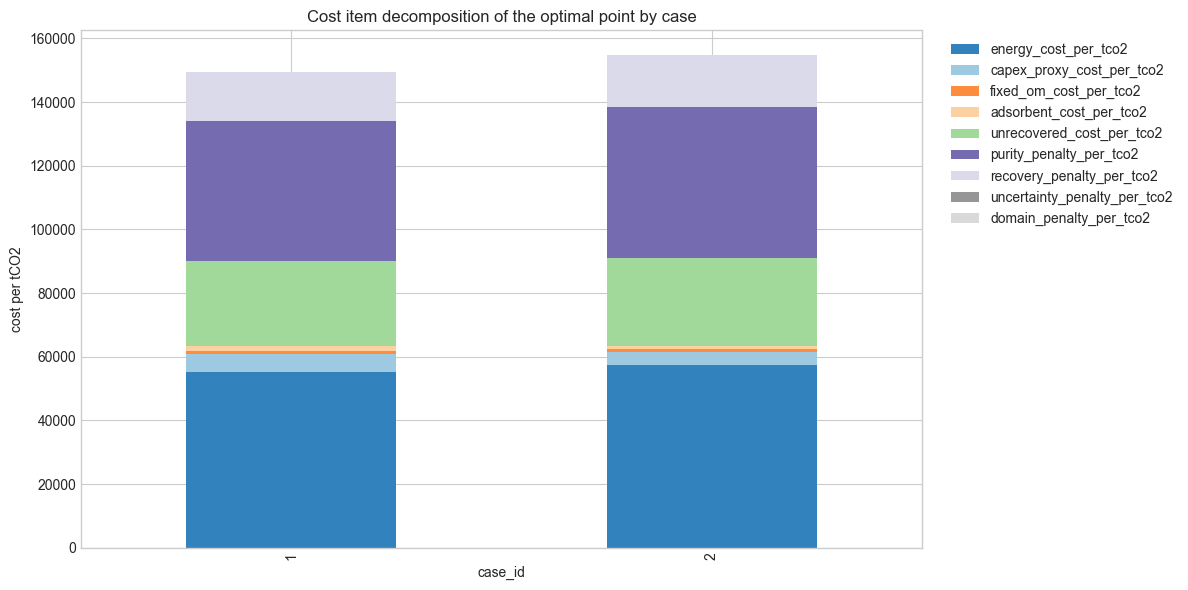

In [7]:
# 주요 비용 항목만 골라서 stacked bar chart를 그린다.

cost_cols = [
    'energy_cost_per_tco2',
    'capex_proxy_cost_per_tco2',
    'fixed_om_cost_per_tco2',
    'adsorbent_cost_per_tco2',
    'unrecovered_cost_per_tco2',
    'purity_penalty_per_tco2',
    'recovery_penalty_per_tco2',
    'uncertainty_penalty_per_tco2',
    'domain_penalty_per_tco2',
]

available_cost_cols = [col for col in cost_cols if col in summary_df.columns]
missing_cost_cols = [col for col in cost_cols if col not in summary_df.columns]
if missing_cost_cols:
    print(f'요약 테이블에 없는 비용 컬럼은 제외합니다: {missing_cost_cols}')

plot_df = summary_df[['case_id'] + available_cost_cols].copy()
plot_df = plot_df.set_index('case_id')

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20c',
)
ax.set_title('Cost item decomposition of the optimal point by case')
ax.set_xlabel('case_id')
ax.set_ylabel('cost per tCO2')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


## 7. 특정 가스 상태의 후보 해 탐색 결과 보기

아래 셀에서 `selected_case_id`를 바꾸면, 해당 케이스에서 어떤 조건들이 낮은 비용을 보였는지 확인할 수 있습니다.

In [8]:
# 특정 가스 상태에 대해 상위 후보들을 정렬해서 본다.

selected_case_id = 1

candidate_view_cols = [
    'case_id',
    'tADS', 'PL', 'v0', 't_press', 't_depress',
    'pred_CO2_purity', 'pred_CO2_recovery',
    'specific_energy_kwh_per_tco2',
    'energy_cost_per_tco2',
    'capex_proxy_cost_per_tco2',
    'adsorbent_cost_per_tco2',
    'unrecovered_cost_per_tco2',
    'total_cost_per_tco2',
]

all_candidates_df.loc[
    all_candidates_df['case_id'].eq(selected_case_id),
    candidate_view_cols,
].sort_values('total_cost_per_tco2').head(20)


,case_id,tADS,PL,v0,t_press,t_depress,pred_CO2_purity,pred_CO2_recovery,specific_energy_kwh_per_tco2,energy_cost_per_tco2,capex_proxy_cost_per_tco2,adsorbent_cost_per_tco2,unrecovered_cost_per_tco2,total_cost_per_tco2
0,1,180.0,0.348207,0.032,20.202850,75.0,0.431351,0.651999,500.773965,55085.136190,5677.588822,1538.413176,26687.192503,149487.618022
1,1,180.0,0.347398,0.032,20.192469,75.0,0.431214,0.652219,501.107990,55121.878855,5675.538424,1537.857595,26661.318066,149494.003395
2,1,180.0,0.347906,0.032,20.622706,75.0,0.431289,0.652061,500.911242,55100.236620,5682.501404,1539.744301,26679.909172,149506.717986
3,1,180.0,0.350000,0.032,20.148905,75.0,0.431639,0.651523,500.056852,55006.253760,5681.041015,1539.348591,26743.290343,149507.039535
4,1,180.0,0.350000,0.032,20.158210,75.0,0.431639,0.651522,500.056952,55006.264745,5681.172339,1539.384175,26743.430761,149507.544266
5,1,180.0,0.350000,0.032,20.159319,75.0,0.431639,0.651521,500.056952,55006.264757,5681.187784,1539.388360,26743.444803,149507.595689
6,1,180.0,0.349746,0.032,20.993760,75.0,0.431592,0.651536,500.164890,55018.137935,5691.907473,1542.292992,26741.766845,149508.667439
7,1,180.0,0.350000,0.032,20.190334,75.0,0.431638,0.651518,500.057182,55006.290075,5681.624634,1539.506730,26743.901164,149509.240465
8,1,180.0,0.350000,0.032,20.247692,75.0,0.431638,0.651510,500.057672,55006.343929,5682.432954,1539.725754,26744.750712,149512.307485
9,1,180.0,0.350000,0.032,20.261594,75.0,0.431638,0.651509,500.057792,55006.357132,5682.629212,1539.778932,26744.961347,149513.062198
